Load best SAC evaluation results and make threshold-by-environment graph

===== RESULTS LOADED =====
Shape: (28800, 10)
   step  envId  formationType  timeStep  receiverId  old_threshold   delta_T  \
0     0      0              0         1           2      10.000000 -1.430287   
1     1      0              0         1           3       8.569713 -1.264756   
2     2      0              0         1           4       7.304957 -1.069986   
3     3      0              0         1           5       6.234970 -1.008042   
4     4      0              0         1           6       5.226928 -1.061357   

   new_threshold  benign_exceedance_rate    reward  
0       8.569713                     0.0 -0.031527  
1       7.304957                     0.0 -0.025801  
2       6.234970                     0.0 -0.020184  
3       5.226928                     0.0 -0.017888  
4       4.165571                     0.0 -0.017930  

===== LEARNED THRESHOLD BY ENVIRONMENT =====
   envId     envName  count       mean       std        min     median  \
0      0     Perfect   7199   1.004

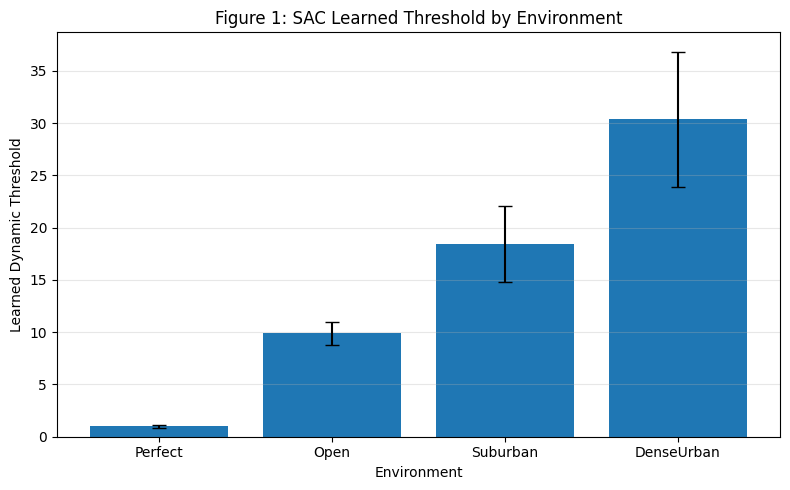


Saved:
figure1_sac_threshold_by_environment.png
figure1_sac_threshold_by_environment.pdf
figure1_threshold_by_environment_summary.csv


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# ============================================================
# Load best SAC evaluation results
# ============================================================

results_path = "sac_hpc_runs/sac_lam2_005/evaluation_results.csv"

results_df = pd.read_csv(results_path)

print("===== RESULTS LOADED =====")
print("Shape:", results_df.shape)
print(results_df.head())

# ============================================================
# Environment labels
# ============================================================

env_labels = {
    0: "Perfect",
    1: "Open",
    2: "Suburban",
    3: "DenseUrban"
}

results_df["envName"] = results_df["envId"].map(env_labels)

# ============================================================
# Summary table: learned threshold by environment
# ============================================================

threshold_summary = (
    results_df
    .groupby(["envId", "envName"])["new_threshold"]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .reset_index()
)

print("\n===== LEARNED THRESHOLD BY ENVIRONMENT =====")
print(threshold_summary)

# Save summary table
threshold_summary.to_csv("figure1_threshold_by_environment_summary.csv", index=False)

# ============================================================
# Figure 1: Bar chart with error bars
# ============================================================

# Keep correct environment order
threshold_summary = threshold_summary.sort_values("envId")

plt.figure(figsize=(8, 5))

plt.bar(
    threshold_summary["envName"],
    threshold_summary["mean"],
    yerr=threshold_summary["std"],
    capsize=5
)

plt.xlabel("Environment")
plt.ylabel("Learned Dynamic Threshold")
plt.title("Figure 1: SAC Learned Threshold by Environment")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

# Save figure
plt.savefig("figure1_sac_threshold_by_environment.png", dpi=300)
plt.savefig("figure1_sac_threshold_by_environment.pdf")

plt.show()

print("\nSaved:")
print("figure1_sac_threshold_by_environment.png")
print("figure1_sac_threshold_by_environment.pdf")
print("figure1_threshold_by_environment_summary.csv")

Learned threshold by environment and formation

===== THRESHOLD BY ENVIRONMENT + FORMATION =====
    envId     envName  formationType  formationName  count       mean  \
0       0     Perfect              0     Horizontal   2399   1.012716   
1       0     Perfect              1  Random-Matrix   2400   1.000000   
2       0     Perfect              2       Circular   2400   1.001439   
3       1        Open              0     Horizontal   2400  11.201243   
4       1        Open              1  Random-Matrix   2400   8.955134   
5       1        Open              2       Circular   2400   9.569639   
6       2    Suburban              0     Horizontal   2400  23.388666   
7       2    Suburban              1  Random-Matrix   2400  15.350625   
8       2    Suburban              2       Circular   2400  16.598281   
9       3  DenseUrban              0     Horizontal   2400  39.395132   
10      3  DenseUrban              1  Random-Matrix   2400  26.094193   
11      3  DenseUrban              2       Circular   2401  25.579810   

 

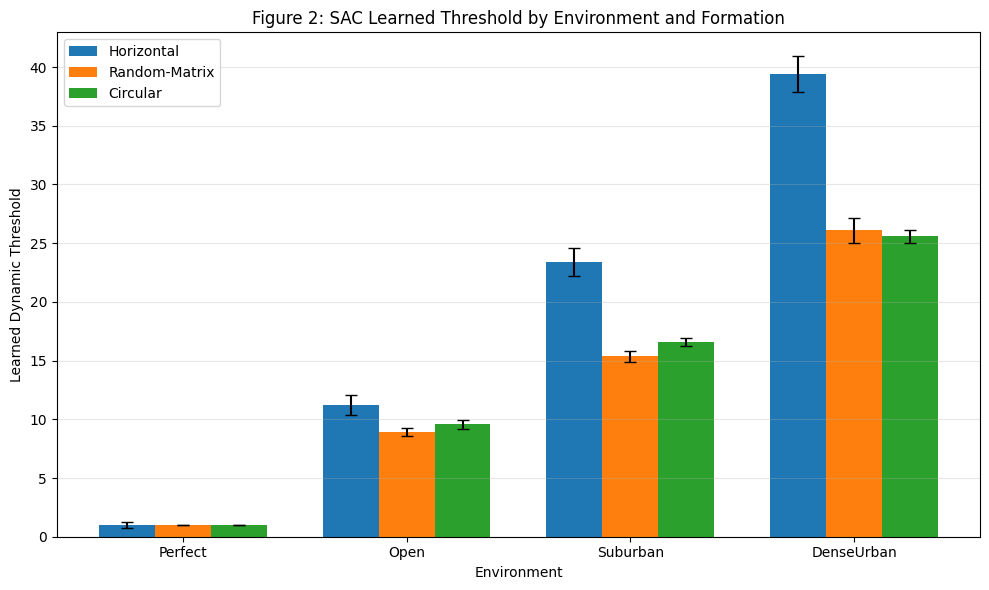


Saved:
figure2_sac_threshold_by_env_formation.png
figure2_sac_threshold_by_env_formation.pdf
figure2_threshold_by_env_formation_summary.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Load results
# ============================================================
results_path = "sac_hpc_runs/sac_lam2_005/evaluation_results.csv"
results_df = pd.read_csv(results_path)

# ============================================================
# Label mappings
# ============================================================
env_labels = {
    0: "Perfect",
    1: "Open",
    2: "Suburban",
    3: "DenseUrban"
}

formation_labels = {
    0: "Horizontal",
    1: "Random-Matrix",
    2: "Circular"
}

results_df["envName"] = results_df["envId"].map(env_labels)
results_df["formationName"] = results_df["formationType"].map(formation_labels)

# ============================================================
# Group summary
# ============================================================
group_summary = (
    results_df
    .groupby(["envId", "envName", "formationType", "formationName"])["new_threshold"]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .reset_index()
)

print("===== THRESHOLD BY ENVIRONMENT + FORMATION =====")
print(group_summary)

group_summary.to_csv("figure2_threshold_by_env_formation_summary.csv", index=False)

# ============================================================
# Prepare grouped bar chart
# ============================================================
env_order = ["Perfect", "Open", "Suburban", "DenseUrban"]
formation_order = ["Horizontal", "Random-Matrix", "Circular"]

pivot_mean = group_summary.pivot(index="envName", columns="formationName", values="mean")
pivot_std = group_summary.pivot(index="envName", columns="formationName", values="std")

pivot_mean = pivot_mean.loc[env_order, formation_order]
pivot_std = pivot_std.loc[env_order, formation_order]

x = np.arange(len(env_order))
width = 0.25

plt.figure(figsize=(10, 6))

for i, formation in enumerate(formation_order):
    plt.bar(
        x + (i - 1) * width,
        pivot_mean[formation],
        width=width,
        yerr=pivot_std[formation],
        capsize=4,
        label=formation
    )

plt.xticks(x, env_order)
plt.xlabel("Environment")
plt.ylabel("Learned Dynamic Threshold")
plt.title("Figure 2: SAC Learned Threshold by Environment and Formation")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig("figure2_sac_threshold_by_env_formation.png", dpi=300)
plt.savefig("figure2_sac_threshold_by_env_formation.pdf")
plt.show()

print("\nSaved:")
print("figure2_sac_threshold_by_env_formation.png")
print("figure2_sac_threshold_by_env_formation.pdf")
print("figure2_threshold_by_env_formation_summary.csv")

benign exceedance by environment

===== BENIGN EXCEEDANCE BY ENVIRONMENT =====
   envId     envName  count      mean       std  min    median       max
0      0     Perfect   7199  0.000000  0.000000  0.0  0.000000  0.000000
1      1        Open   7200  0.087142  0.070872  0.0  0.052632  0.842105
2      2    Suburban   7200  0.079671  0.068095  0.0  0.052632  0.526316
3      3  DenseUrban   7201  0.092991  0.072504  0.0  0.105263  0.578947


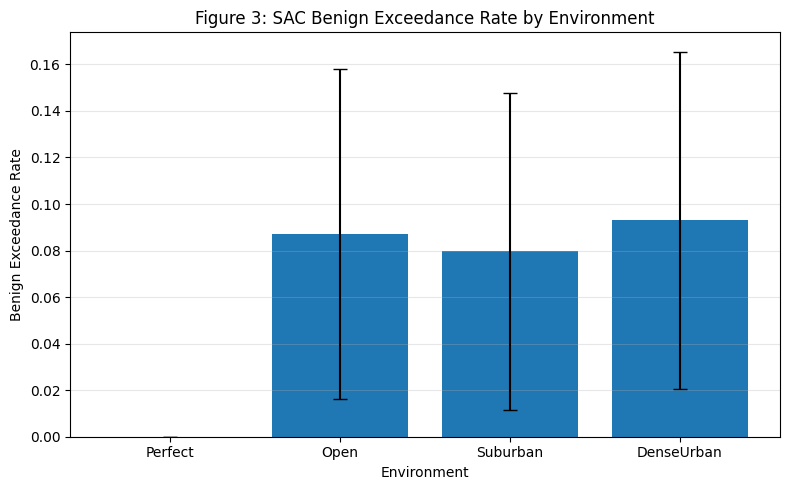


Saved:
figure3_sac_exceedance_by_environment.png
figure3_sac_exceedance_by_environment.pdf
figure3_exceedance_by_environment_summary.csv


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Load SAC evaluation results
# ============================================================
results_path = "sac_hpc_runs/sac_lam2_005/evaluation_results.csv"
results_df = pd.read_csv(results_path)

# ============================================================
# Environment labels
# ============================================================
env_labels = {
    0: "Perfect",
    1: "Open",
    2: "Suburban",
    3: "DenseUrban"
}

results_df["envName"] = results_df["envId"].map(env_labels)

# ============================================================
# Summary
# ============================================================
exceed_summary = (
    results_df
    .groupby(["envId", "envName"])["benign_exceedance_rate"]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .reset_index()
)

print("===== BENIGN EXCEEDANCE BY ENVIRONMENT =====")
print(exceed_summary)

# Save summary
exceed_summary.to_csv("figure3_exceedance_by_environment_summary.csv", index=False)

# ============================================================
# Plot
# ============================================================
plt.figure(figsize=(8, 5))
plt.bar(
    exceed_summary["envName"],
    exceed_summary["mean"],
    yerr=exceed_summary["std"],
    capsize=5
)

plt.xlabel("Environment")
plt.ylabel("Benign Exceedance Rate")
plt.title("Figure 3: SAC Benign Exceedance Rate by Environment")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig("figure3_sac_exceedance_by_environment.png", dpi=300)
plt.savefig("figure3_sac_exceedance_by_environment.pdf")
plt.show()

print("\nSaved:")
print("figure3_sac_exceedance_by_environment.png")
print("figure3_sac_exceedance_by_environment.pdf")
print("figure3_exceedance_by_environment_summary.csv")

Static vs SAC exceedance comparison

===== STATIC VS SAC BENIGN EXCEEDANCE =====
   envId  static_exceedance  sac_exceedance     envName
0      0           0.000000        0.000000     Perfect
1      1           0.085175        0.087142        Open
2      2           0.272076        0.079671    Suburban
3      3           0.516301        0.092991  DenseUrban


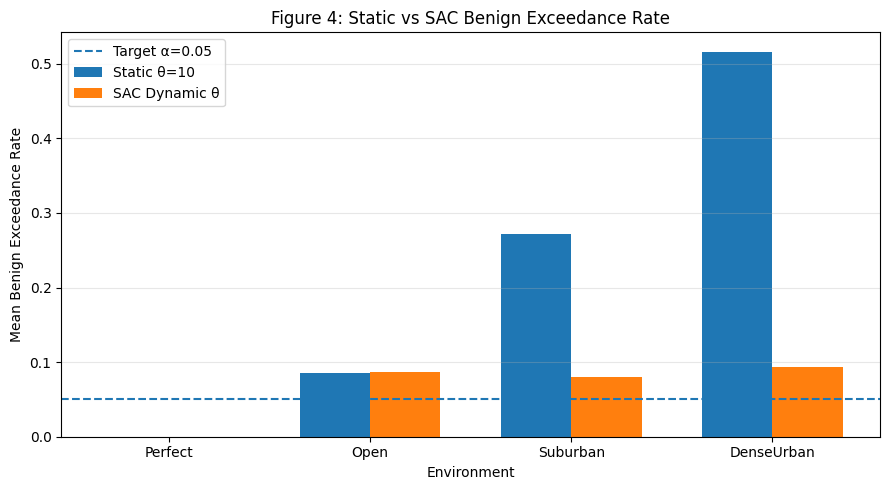


Saved:
figure4_static_vs_sac_exceedance.png
figure4_static_vs_sac_exceedance.pdf
figure4_static_vs_sac_exceedance_summary.csv


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Load data
# ============================================================
sac_results_path = "sac_hpc_runs/sac_lam2_005/evaluation_results.csv"
det_path = "../uav_detection_dataset-updated.csv"

sac_df = pd.read_csv(sac_results_path)
det_df = pd.read_csv(det_path)

# ============================================================
# Labels
# ============================================================
env_labels = {
    0: "Perfect",
    1: "Open",
    2: "Suburban",
    3: "DenseUrban"
}

sac_df["envName"] = sac_df["envId"].map(env_labels)

# ============================================================
# Static exceedance rate using theta = 10
# ============================================================
static_theta = 10

benign_det = det_df[det_df["actual_target_malicious"] == 0].copy()
benign_det["static_exceeded"] = (benign_det["delta_d"] > static_theta).astype(int)

static_summary = (
    benign_det
    .groupby("envId")["static_exceeded"]
    .mean()
    .reset_index()
    .rename(columns={"static_exceeded": "static_exceedance"})
)

# ============================================================
# SAC exceedance rate
# ============================================================
sac_summary = (
    sac_df
    .groupby("envId")["benign_exceedance_rate"]
    .mean()
    .reset_index()
    .rename(columns={"benign_exceedance_rate": "sac_exceedance"})
)

# ============================================================
# Merge summaries
# ============================================================
compare_df = static_summary.merge(sac_summary, on="envId")
compare_df["envName"] = compare_df["envId"].map(env_labels)

print("===== STATIC VS SAC BENIGN EXCEEDANCE =====")
print(compare_df)

compare_df.to_csv("figure4_static_vs_sac_exceedance_summary.csv", index=False)

# ============================================================
# Plot grouped bar chart
# ============================================================
env_order = ["Perfect", "Open", "Suburban", "DenseUrban"]
compare_df = compare_df.sort_values("envId")

x = np.arange(len(env_order))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width/2,
    compare_df["static_exceedance"],
    width,
    label="Static θ=10"
)

plt.bar(
    x + width/2,
    compare_df["sac_exceedance"],
    width,
    label="SAC Dynamic θ"
)

plt.axhline(
    y=0.05,
    linestyle="--",
    linewidth=1.5,
    label="Target α=0.05"
)

plt.xticks(x, env_order)
plt.xlabel("Environment")
plt.ylabel("Mean Benign Exceedance Rate")
plt.title("Figure 4: Static vs SAC Benign Exceedance Rate")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig("figure4_static_vs_sac_exceedance.png", dpi=300)
plt.savefig("figure4_static_vs_sac_exceedance.pdf")
plt.show()

print("\nSaved:")
print("figure4_static_vs_sac_exceedance.png")
print("figure4_static_vs_sac_exceedance.pdf")
print("figure4_static_vs_sac_exceedance_summary.csv")

SAC reward by environment

===== SAC REWARD BY ENVIRONMENT =====
   envId     envName  count      mean       std       min    median       max
0      0     Perfect   7199 -0.003680  0.000621 -0.031527 -0.003598 -0.003500
1      1        Open   7200 -0.017043  0.014516 -0.670018 -0.012697 -0.007478
2      2    Suburban   7200 -0.024662  0.012256 -0.243805 -0.020355 -0.014256
3      3  DenseUrban   7201 -0.037945  0.014122 -0.336358 -0.037324 -0.024570


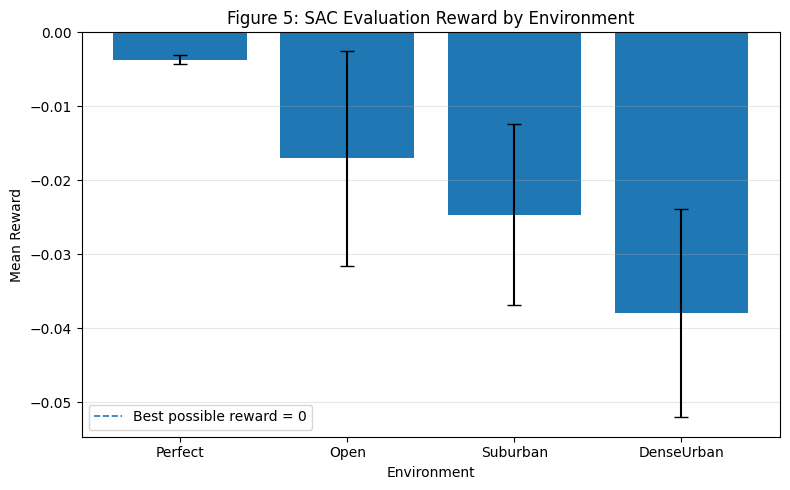


Saved:
figure5_sac_reward_by_environment.png
figure5_sac_reward_by_environment.pdf
figure5_reward_by_environment_summary.csv


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Load SAC evaluation results
# ============================================================
results_path = "sac_hpc_runs/sac_lam2_005/evaluation_results.csv"
results_df = pd.read_csv(results_path)

# ============================================================
# Environment labels
# ============================================================
env_labels = {
    0: "Perfect",
    1: "Open",
    2: "Suburban",
    3: "DenseUrban"
}

results_df["envName"] = results_df["envId"].map(env_labels)

# ============================================================
# Reward summary
# ============================================================
reward_summary = (
    results_df
    .groupby(["envId", "envName"])["reward"]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .reset_index()
    .sort_values("envId")
)

print("===== SAC REWARD BY ENVIRONMENT =====")
print(reward_summary)

reward_summary.to_csv("figure5_reward_by_environment_summary.csv", index=False)

# ============================================================
# Plot reward by environment
# ============================================================
plt.figure(figsize=(8, 5))

plt.bar(
    reward_summary["envName"],
    reward_summary["mean"],
    yerr=reward_summary["std"],
    capsize=5
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1.2,
    label="Best possible reward = 0"
)

plt.xlabel("Environment")
plt.ylabel("Mean Reward")
plt.title("Figure 5: SAC Evaluation Reward by Environment")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("figure5_sac_reward_by_environment.png", dpi=300)
plt.savefig("figure5_sac_reward_by_environment.pdf")
plt.show()

print("\nSaved:")
print("figure5_sac_reward_by_environment.png")
print("figure5_sac_reward_by_environment.pdf")
print("figure5_reward_by_environment_summary.csv")

SAC reward by environment and formation.

===== SAC REWARD BY ENVIRONMENT + FORMATION =====
    envId     envName  formationType  formationName  count      mean  \
0       0     Perfect              0     Horizontal   2399 -0.003814   
1       0     Perfect              1  Random-Matrix   2400 -0.003587   
2       0     Perfect              2       Circular   2400 -0.003637   
3       1        Open              0     Horizontal   2400 -0.021441   
4       1        Open              1  Random-Matrix   2400 -0.015292   
5       1        Open              2       Circular   2400 -0.014396   
6       2    Suburban              0     Horizontal   2400 -0.029590   
7       2    Suburban              1  Random-Matrix   2400 -0.022360   
8       2    Suburban              2       Circular   2400 -0.022036   
9       3  DenseUrban              0     Horizontal   2400 -0.045635   
10      3  DenseUrban              1  Random-Matrix   2400 -0.032418   
11      3  DenseUrban              2       Circular   2401 -0.035783   

         std 

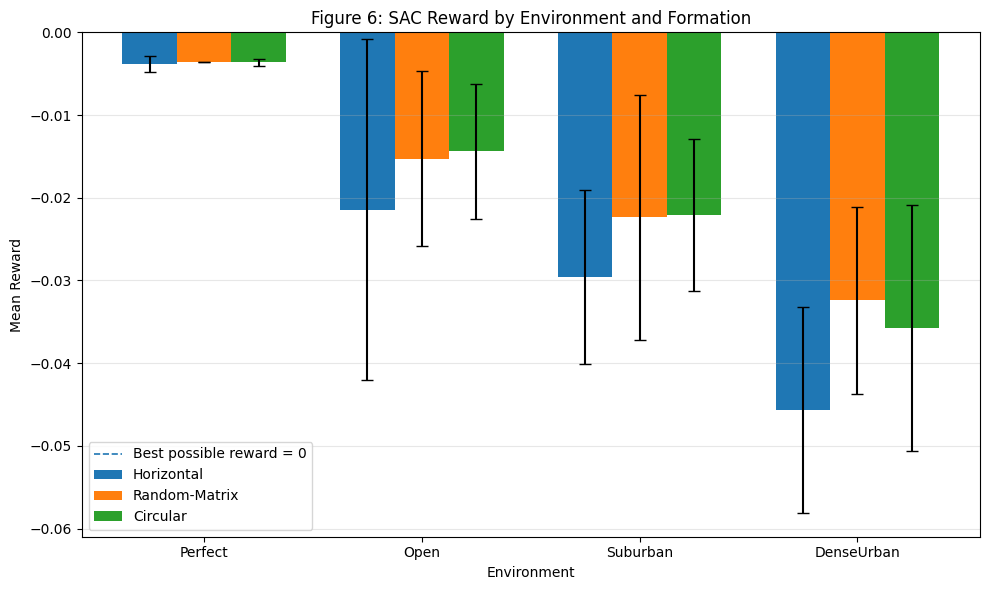


Saved:
figure6_sac_reward_by_env_formation.png
figure6_sac_reward_by_env_formation.pdf
figure6_reward_by_env_formation_summary.csv


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Load SAC evaluation results
# ============================================================
results_path = "sac_hpc_runs/sac_lam2_005/evaluation_results.csv"
results_df = pd.read_csv(results_path)

# ============================================================
# Label mappings
# ============================================================
env_labels = {
    0: "Perfect",
    1: "Open",
    2: "Suburban",
    3: "DenseUrban"
}

formation_labels = {
    0: "Horizontal",
    1: "Random-Matrix",
    2: "Circular"
}

results_df["envName"] = results_df["envId"].map(env_labels)
results_df["formationName"] = results_df["formationType"].map(formation_labels)

# ============================================================
# Reward summary by environment + formation
# ============================================================
reward_form_summary = (
    results_df
    .groupby(["envId", "envName", "formationType", "formationName"])["reward"]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .reset_index()
    .sort_values(["envId", "formationType"])
)

print("===== SAC REWARD BY ENVIRONMENT + FORMATION =====")
print(reward_form_summary)

reward_form_summary.to_csv("figure6_reward_by_env_formation_summary.csv", index=False)

# ============================================================
# Prepare grouped bar chart
# ============================================================
env_order = ["Perfect", "Open", "Suburban", "DenseUrban"]
formation_order = ["Horizontal", "Random-Matrix", "Circular"]

pivot_mean = reward_form_summary.pivot(
    index="envName",
    columns="formationName",
    values="mean"
)

pivot_std = reward_form_summary.pivot(
    index="envName",
    columns="formationName",
    values="std"
)

pivot_mean = pivot_mean.loc[env_order, formation_order]
pivot_std = pivot_std.loc[env_order, formation_order]

x = np.arange(len(env_order))
width = 0.25

plt.figure(figsize=(10, 6))

for i, formation in enumerate(formation_order):
    plt.bar(
        x + (i - 1) * width,
        pivot_mean[formation],
        width=width,
        yerr=pivot_std[formation],
        capsize=4,
        label=formation
    )

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1.2,
    label="Best possible reward = 0"
)

plt.xticks(x, env_order)
plt.xlabel("Environment")
plt.ylabel("Mean Reward")
plt.title("Figure 6: SAC Reward by Environment and Formation")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig("figure6_sac_reward_by_env_formation.png", dpi=300)
plt.savefig("figure6_sac_reward_by_env_formation.pdf")
plt.show()

print("\nSaved:")
print("figure6_sac_reward_by_env_formation.png")
print("figure6_sac_reward_by_env_formation.pdf")
print("figure6_reward_by_env_formation_summary.csv")

Static vs SAC Benign Exceedance by Environment and Formation

===== STATIC VS SAC EXCEEDANCE BY ENV + FORMATION =====
    envId     envName  formationType  formationName  static_exceedance  \
0       0     Perfect              0     Horizontal           0.000000   
1       0     Perfect              1  Random-Matrix           0.000000   
2       0     Perfect              2       Circular           0.000000   
3       1        Open              0     Horizontal           0.130987   
4       1        Open              1  Random-Matrix           0.057675   
5       1        Open              2       Circular           0.066864   
6       2    Suburban              0     Horizontal           0.329013   
7       2    Suburban              1  Random-Matrix           0.225526   
8       2    Suburban              2       Circular           0.261689   
9       3  DenseUrban              0     Horizontal           0.566053   
10      3  DenseUrban              1  Random-Matrix           0.469803   
11      3  DenseUrban              2       Circular     

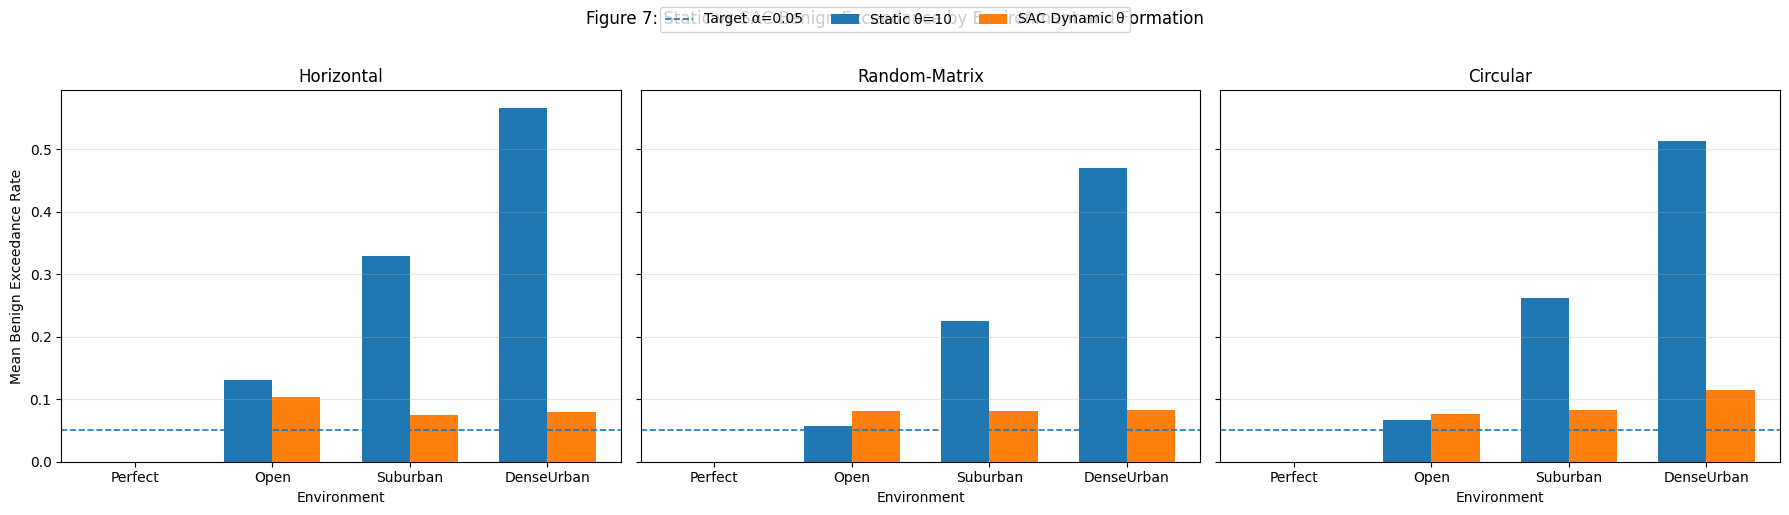


Saved:
figure7_static_vs_sac_by_env_formation.png
figure7_static_vs_sac_by_env_formation.pdf
figure7_static_vs_sac_by_env_formation.csv


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Load SAC evaluation results
# ============================================================
sac_path = "sac_hpc_runs/sac_lam2_005/evaluation_results.csv"
sac_df = pd.read_csv(sac_path)

# ============================================================
# Load static reward dataset (theta = 10 baseline)
# ============================================================
static_path = "../uav_rl_reward_dataset.csv"
static_df = pd.read_csv(static_path)

# ============================================================
# Label mappings
# ============================================================
env_labels = {
    0: "Perfect",
    1: "Open",
    2: "Suburban",
    3: "DenseUrban"
}

formation_labels = {
    0: "Horizontal",
    1: "Random-Matrix",
    2: "Circular"
}

sac_df["envName"] = sac_df["envId"].map(env_labels)
sac_df["formationName"] = sac_df["formationType"].map(formation_labels)

static_df["envName"] = static_df["envId"].map(env_labels)
static_df["formationName"] = static_df["formationType"].map(formation_labels)

# ============================================================
# SAC exceedance summary
# ============================================================
sac_summary = (
    sac_df.groupby(["envId", "envName", "formationType", "formationName"])["benign_exceedance_rate"]
    .mean()
    .reset_index()
    .rename(columns={"benign_exceedance_rate": "sac_exceedance"})
)

# ============================================================
# Static exceedance summary
# ============================================================
static_summary = (
    static_df.groupby(["envId", "envName", "formationType", "formationName"])["benign_exceedance_rate"]
    .mean()
    .reset_index()
    .rename(columns={"benign_exceedance_rate": "static_exceedance"})
)

# ============================================================
# Merge
# ============================================================
compare_df = pd.merge(
    static_summary,
    sac_summary,
    on=["envId", "envName", "formationType", "formationName"],
    how="inner"
)

compare_df["improvement"] = compare_df["static_exceedance"] - compare_df["sac_exceedance"]

print("===== STATIC VS SAC EXCEEDANCE BY ENV + FORMATION =====")
print(compare_df)

compare_df.to_csv("figure7_static_vs_sac_by_env_formation.csv", index=False)

# ============================================================
# Plot
# ============================================================
env_order = ["Perfect", "Open", "Suburban", "DenseUrban"]
formation_order = ["Horizontal", "Random-Matrix", "Circular"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for idx, formation in enumerate(formation_order):
    ax = axes[idx]

    sub = compare_df[compare_df["formationName"] == formation].copy()
    sub = sub.set_index("envName").loc[env_order].reset_index()

    x = np.arange(len(env_order))
    width = 0.35

    ax.bar(x - width/2, sub["static_exceedance"], width=width, label="Static θ=10")
    ax.bar(x + width/2, sub["sac_exceedance"], width=width, label="SAC Dynamic θ")

    ax.axhline(y=0.05, linestyle="--", linewidth=1.2, label="Target α=0.05")
    ax.set_xticks(x)
    ax.set_xticklabels(env_order, rotation=0)
    ax.set_title(formation)
    ax.set_xlabel("Environment")
    ax.grid(axis="y", alpha=0.3)

    if idx == 0:
        ax.set_ylabel("Mean Benign Exceedance Rate")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)
fig.suptitle("Figure 7: Static vs SAC Benign Exceedance by Environment and Formation", y=1.02)
plt.tight_layout()

plt.savefig("figure7_static_vs_sac_by_env_formation.png", dpi=300, bbox_inches="tight")
plt.savefig("figure7_static_vs_sac_by_env_formation.pdf", bbox_inches="tight")
plt.show()

print("\nSaved:")
print("figure7_static_vs_sac_by_env_formation.png")
print("figure7_static_vs_sac_by_env_formation.pdf")
print("figure7_static_vs_sac_by_env_formation.csv")


SAC Improvement Heatmap

===== IMPROVEMENT HEATMAP TABLE =====
envName        Perfect      Open  Suburban  DenseUrban
formationName                                         
Horizontal         0.0  0.026952  0.254079    0.485702
Random-Matrix      0.0 -0.023158  0.143991    0.386491
Circular           0.0 -0.009693  0.179145    0.397745


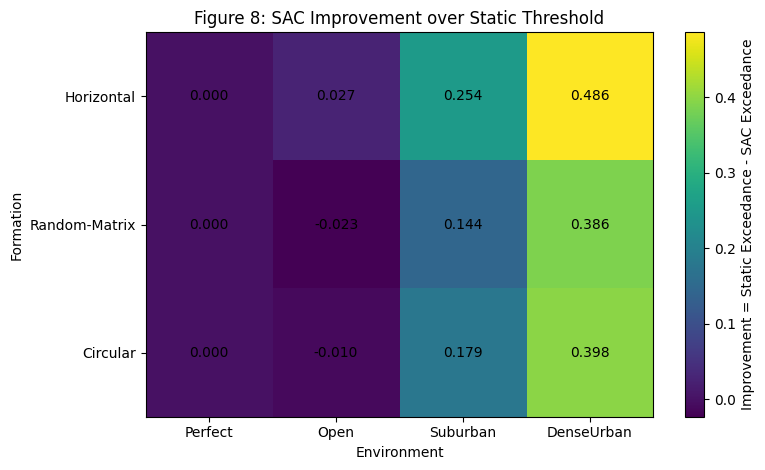


Saved:
figure8_sac_improvement_heatmap.png
figure8_sac_improvement_heatmap.pdf
figure8_improvement_heatmap_table.csv


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# compare_df already has:
# envId, envName, formationType, formationName,
# static_exceedance, sac_exceedance, improvement

# Make pivot table for heatmap
heatmap_df = compare_df.pivot(
    index="formationName",
    columns="envName",
    values="improvement"
)

# Reorder columns and rows
heatmap_df = heatmap_df[["Perfect", "Open", "Suburban", "DenseUrban"]]
heatmap_df = heatmap_df.loc[["Horizontal", "Random-Matrix", "Circular"]]

print("===== IMPROVEMENT HEATMAP TABLE =====")
print(heatmap_df)

heatmap_df.to_csv("figure8_improvement_heatmap_table.csv")

# Plot heatmap manually using matplotlib
fig, ax = plt.subplots(figsize=(8, 4.8))

im = ax.imshow(heatmap_df.values, aspect="auto")

# Labels
ax.set_xticks(np.arange(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns)
ax.set_yticks(np.arange(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)

# Add values inside cells
for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        val = heatmap_df.iloc[i, j]
        ax.text(j, i, f"{val:.3f}", ha="center", va="center")

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Improvement = Static Exceedance - SAC Exceedance")

plt.title("Figure 8: SAC Improvement over Static Threshold")
plt.xlabel("Environment")
plt.ylabel("Formation")

plt.tight_layout()
plt.savefig("figure8_sac_improvement_heatmap.png", dpi=300, bbox_inches="tight")
plt.savefig("figure8_sac_improvement_heatmap.pdf", bbox_inches="tight")
plt.show()

print("\nSaved:")
print("figure8_sac_improvement_heatmap.png")
print("figure8_sac_improvement_heatmap.pdf")
print("figure8_improvement_heatmap_table.csv")

Threshold distribution (boxplot) by environment

===== THRESHOLD DISTRIBUTION SUMMARY =====
             count       mean       std        min        25%        50%  \
envName                                                                    
Perfect     7199.0   1.004717  0.148201   1.000000   1.000000   1.000000   
Open        7200.0   9.908672  1.102280   1.000000   9.101270   9.568361   
Suburban    7200.0  18.445857  3.616738   9.234850  15.525844  16.608876   
DenseUrban  7201.0  30.355715  6.489887  15.868914  25.660752  26.114393   

                  75%        max  
envName                           
Perfect      1.000000   8.569713  
Open        10.645572  13.485421  
Suburban    22.891781  25.978355  
DenseUrban  39.077808  42.117149  


C:\Users\qasim\AppData\Local\Temp\ipykernel_21080\769704615.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


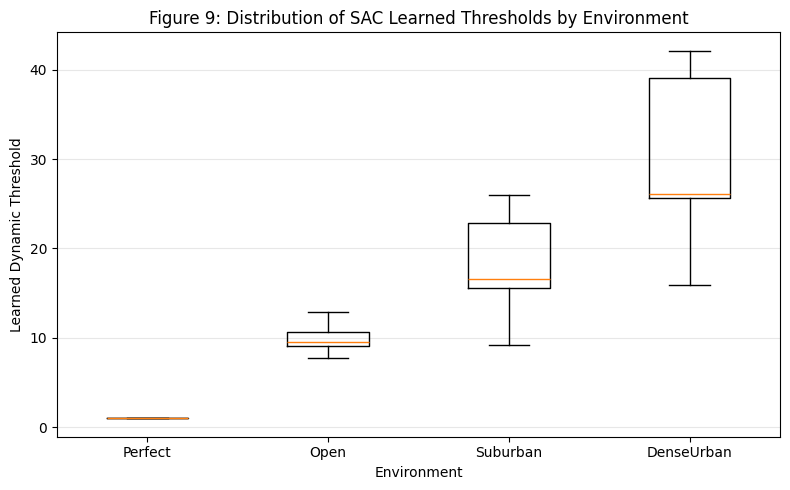


Saved:
figure9_threshold_distribution_by_environment.png
figure9_threshold_distribution_by_environment.pdf
figure9_threshold_distribution_summary.csv


In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Load FINAL best SAC HPC evaluation results
# ============================================================
df = pd.read_csv("sac_hpc_runs/sac_lam2_005/evaluation_results.csv")

env_map = {
    0: "Perfect",
    1: "Open",
    2: "Suburban",
    3: "DenseUrban"
}

df["envName"] = df["envId"].map(env_map)

env_order = ["Perfect", "Open", "Suburban", "DenseUrban"]

# ============================================================
# Summary
# ============================================================
summary = (
    df
    .groupby("envName")["new_threshold"]
    .describe()
    .reindex(env_order)
)

print("===== THRESHOLD DISTRIBUTION SUMMARY =====")
print(summary)

summary.to_csv("figure9_threshold_distribution_summary.csv")

# ============================================================
# Boxplot
# ============================================================
data_to_plot = [
    df[df["envName"] == env]["new_threshold"].values
    for env in env_order
]

plt.figure(figsize=(8, 5))

plt.boxplot(
    data_to_plot,
    labels=env_order,
    showfliers=False
)

plt.title("Figure 9: Distribution of SAC Learned Thresholds by Environment")
plt.xlabel("Environment")
plt.ylabel("Learned Dynamic Threshold")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig("figure9_threshold_distribution_by_environment.png", dpi=300, bbox_inches="tight")
plt.savefig("figure9_threshold_distribution_by_environment.pdf", bbox_inches="tight")

plt.show()

print("\nSaved:")
print("figure9_threshold_distribution_by_environment.png")
print("figure9_threshold_distribution_by_environment.pdf")
print("figure9_threshold_distribution_summary.csv")

Static vs SAC Summary Plot

===== FINAL STATIC VS SAC SUMMARY =====
   envId  static_exceedance  sac_exceedance  mean_sac_threshold     envName  \
0      0           0.000000        0.000000            1.004717     Perfect   
1      1           0.085175        0.087142            9.908672        Open   
2      2           0.272076        0.079671           18.445857    Suburban   
3      3           0.516301        0.092991           30.355715  DenseUrban   

   improvement  percent_reduction  
0     0.000000                NaN  
1    -0.001966          -2.308617  
2     0.192405          70.717356  
3     0.423310          81.988910  


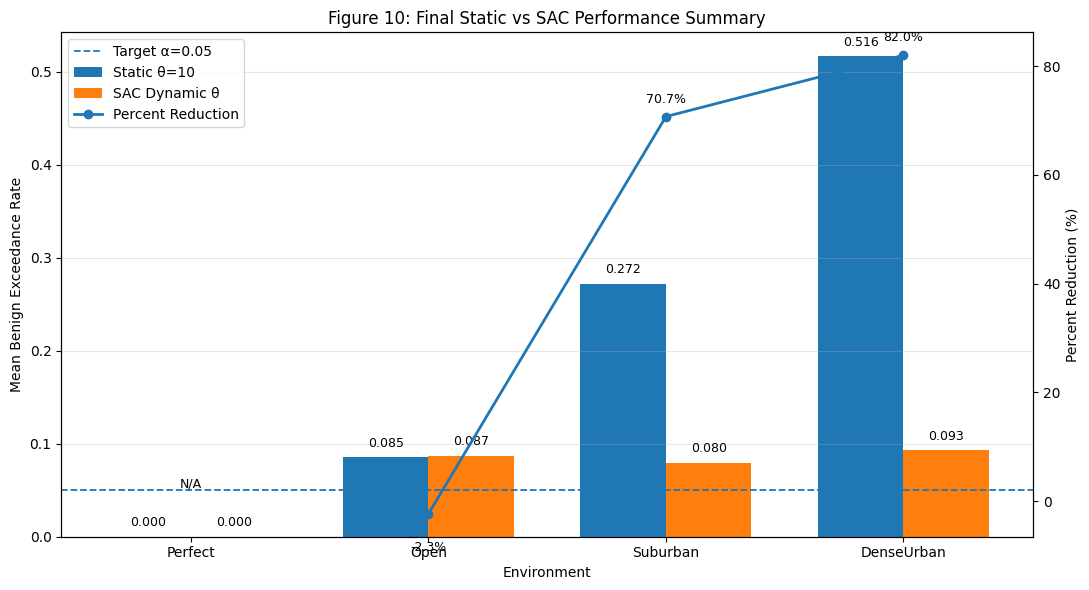


Saved:
figure10_final_static_vs_sac_summary_updated.png
figure10_final_static_vs_sac_summary_updated.pdf
figure10_final_static_vs_sac_summary_updated.csv


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Figure 10: Final Static vs SAC Performance Summary
# Values are computed directly from files
# ============================================================

# -----------------------------
# Load files
# -----------------------------
static_path = "../uav_rl_reward_dataset.csv"
sac_path = "sac_hpc_runs/sac_lam2_005/evaluation_results.csv"

static_df = pd.read_csv(static_path)
sac_df = pd.read_csv(sac_path)

# -----------------------------
# Labels
# -----------------------------
env_labels = {
    0: "Perfect",
    1: "Open",
    2: "Suburban",
    3: "DenseUrban"
}

# -----------------------------
# Static θ=10 exceedance
# uav_rl_reward_dataset.csv already contains benign_exceedance_rate
# computed using static theta = 10
# -----------------------------
static_summary = (
    static_df
    .groupby("envId")["benign_exceedance_rate"]
    .mean()
    .reset_index()
    .rename(columns={"benign_exceedance_rate": "static_exceedance"})
)

# -----------------------------
# SAC dynamic θ exceedance
# -----------------------------
sac_summary = (
    sac_df
    .groupby("envId")["benign_exceedance_rate"]
    .mean()
    .reset_index()
    .rename(columns={"benign_exceedance_rate": "sac_exceedance"})
)

# -----------------------------
# Mean SAC threshold
# -----------------------------
threshold_summary = (
    sac_df
    .groupby("envId")["new_threshold"]
    .mean()
    .reset_index()
    .rename(columns={"new_threshold": "mean_sac_threshold"})
)

# -----------------------------
# Merge summaries
# -----------------------------
summary_df = static_summary.merge(sac_summary, on="envId")
summary_df = summary_df.merge(threshold_summary, on="envId")

summary_df["envName"] = summary_df["envId"].map(env_labels)

summary_df["improvement"] = (
    summary_df["static_exceedance"] - summary_df["sac_exceedance"]
)

summary_df["percent_reduction"] = np.where(
    summary_df["static_exceedance"] > 0,
    (summary_df["improvement"] / summary_df["static_exceedance"]) * 100,
    np.nan
)

summary_df = summary_df.sort_values("envId").reset_index(drop=True)

print("===== FINAL STATIC VS SAC SUMMARY =====")
print(summary_df)

summary_df.to_csv("figure10_final_static_vs_sac_summary_updated.csv", index=False)

# ============================================================
# Plot
# ============================================================

x = np.arange(len(summary_df))
width = 0.36

fig, ax1 = plt.subplots(figsize=(11, 6))

bars_static = ax1.bar(
    x - width / 2,
    summary_df["static_exceedance"],
    width,
    label="Static θ=10"
)

bars_sac = ax1.bar(
    x + width / 2,
    summary_df["sac_exceedance"],
    width,
    label="SAC Dynamic θ"
)

ax1.axhline(
    y=0.05,
    linestyle="--",
    linewidth=1.3,
    label="Target α=0.05"
)

ax1.set_xlabel("Environment")
ax1.set_ylabel("Mean Benign Exceedance Rate")
ax1.set_xticks(x)
ax1.set_xticklabels(summary_df["envName"])
ax1.set_title("Figure 10: Final Static vs SAC Performance Summary")
ax1.grid(axis="y", alpha=0.3)

# -----------------------------
# Add bar labels
# -----------------------------
for bar in bars_static:
    h = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.008,
        f"{h:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

for bar in bars_sac:
    h = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.008,
        f"{h:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# ============================================================
# Percent reduction line on second y-axis
# ============================================================
ax2 = ax1.twinx()

valid_idx = summary_df["percent_reduction"].notna()

ax2.plot(
    x[valid_idx],
    summary_df.loc[valid_idx, "percent_reduction"],
    marker="o",
    linewidth=2,
    label="Percent Reduction"
)

ax2.set_ylabel("Percent Reduction (%)")

# Add percent labels
for xi, pr in zip(x[valid_idx], summary_df.loc[valid_idx, "percent_reduction"]):
    offset = 2 if pr >= 0 else -5
    va = "bottom" if pr >= 0 else "top"

    ax2.text(
        xi,
        pr + offset,
        f"{pr:.1f}%",
        ha="center",
        va=va,
        fontsize=9
    )

# Mark N/A for environments with static exceedance = 0
for idx, row in summary_df.iterrows():
    if pd.isna(row["percent_reduction"]):
        ax2.text(
            x[idx],
            2,
            "N/A",
            ha="center",
            va="bottom",
            fontsize=9
        )

# Combine legends
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper left"
)

plt.tight_layout()

plt.savefig("figure10_final_static_vs_sac_summary_updated.png", dpi=300, bbox_inches="tight")
plt.savefig("figure10_final_static_vs_sac_summary_updated.pdf", bbox_inches="tight")

plt.show()

print("\nSaved:")
print("figure10_final_static_vs_sac_summary_updated.png")
print("figure10_final_static_vs_sac_summary_updated.pdf")
print("figure10_final_static_vs_sac_summary_updated.csv")

RL/SAC Workflow Architecture Diagram

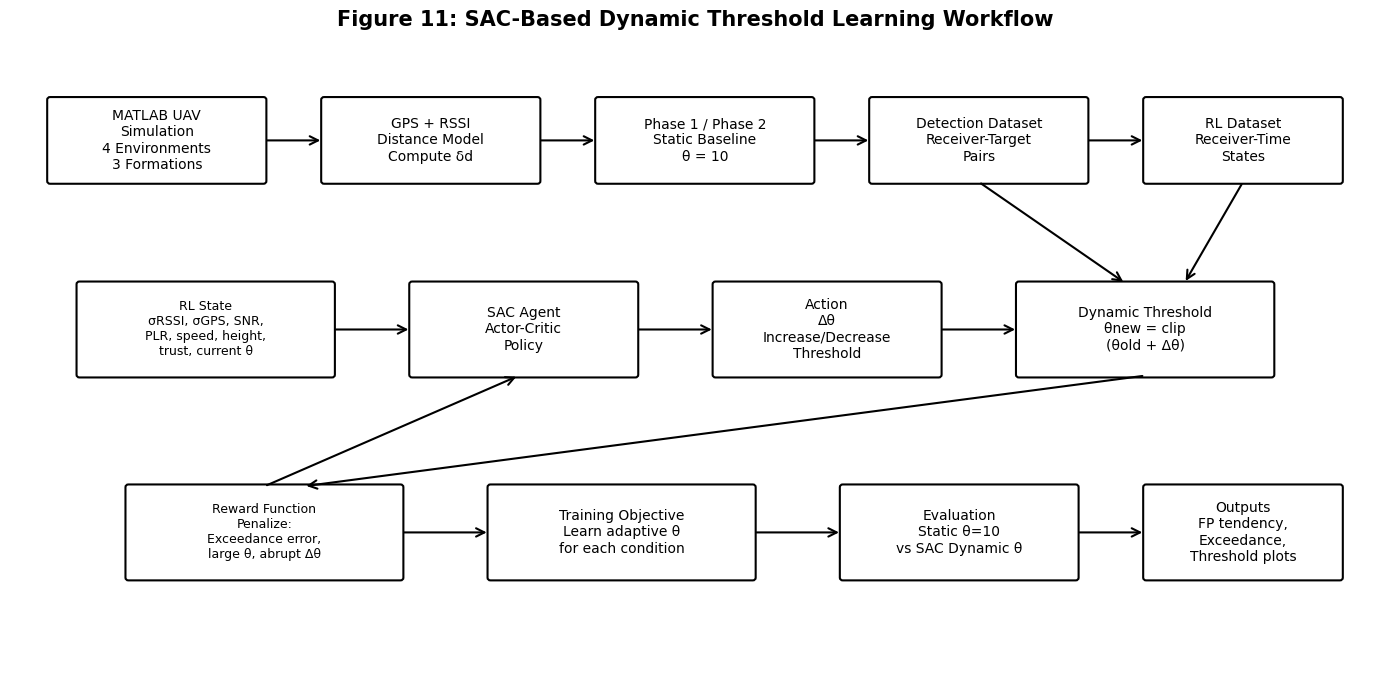

Saved:
figure11_sac_dynamic_threshold_workflow.png
figure11_sac_dynamic_threshold_workflow.pdf


In [18]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# ============================================================
# Helper functions
# ============================================================
def add_box(ax, x, y, w, h, text, fontsize=10):
    box = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.02,rounding_size=0.03",
        linewidth=1.5,
        edgecolor="black",
        facecolor="white"
    )
    ax.add_patch(box)
    ax.text(
        x + w / 2,
        y + h / 2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        wrap=True
    )
    return box

def add_arrow(ax, x1, y1, x2, y2):
    arrow = FancyArrowPatch(
        (x1, y1),
        (x2, y2),
        arrowstyle="->",
        mutation_scale=15,
        linewidth=1.5,
        color="black"
    )
    ax.add_patch(arrow)

# ============================================================
# Create figure
# ============================================================
fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 14)
ax.set_ylim(0, 7)
ax.axis("off")

# ============================================================
# Top row: dataset generation
# ============================================================
add_box(
    ax, 0.4, 5.4, 2.2, 0.9,
    "MATLAB UAV\nSimulation\n4 Environments\n3 Formations"
)

add_box(
    ax, 3.2, 5.4, 2.2, 0.9,
    "GPS + RSSI\nDistance Model\nCompute δd"
)

add_box(
    ax, 6.0, 5.4, 2.2, 0.9,
    "Phase 1 / Phase 2\nStatic Baseline\nθ = 10"
)

add_box(
    ax, 8.8, 5.4, 2.2, 0.9,
    "Detection Dataset\nReceiver-Target\nPairs"
)

add_box(
    ax, 11.6, 5.4, 2.0, 0.9,
    "RL Dataset\nReceiver-Time\nStates"
)

# Arrows top row
add_arrow(ax, 2.6, 5.85, 3.2, 5.85)
add_arrow(ax, 5.4, 5.85, 6.0, 5.85)
add_arrow(ax, 8.2, 5.85, 8.8, 5.85)
add_arrow(ax, 11.0, 5.85, 11.6, 5.85)

# ============================================================
# Middle row: RL environment
# ============================================================
add_box(
    ax, 0.7, 3.3, 2.6, 1.0,
    "RL State\nσRSSI, σGPS, SNR,\nPLR, speed, height,\ntrust, current θ",
    fontsize=9
)

add_box(
    ax, 4.1, 3.3, 2.3, 1.0,
    "SAC Agent\nActor-Critic\nPolicy"
)

add_box(
    ax, 7.2, 3.3, 2.3, 1.0,
    "Action\nΔθ\nIncrease/Decrease\nThreshold"
)

add_box(
    ax, 10.3, 3.3, 2.6, 1.0,
    "Dynamic Threshold\nθnew = clip\n(θold + Δθ)"
)

# Arrows middle row
add_arrow(ax, 3.3, 3.8, 4.1, 3.8)
add_arrow(ax, 6.4, 3.8, 7.2, 3.8)
add_arrow(ax, 9.5, 3.8, 10.3, 3.8)

# Dataset down arrows
add_arrow(ax, 12.6, 5.4, 12.0, 4.3)
add_arrow(ax, 9.9, 5.4, 11.4, 4.3)

# ============================================================
# Bottom row: reward and evaluation
# ============================================================
add_box(
    ax, 1.2, 1.1, 2.8, 1.0,
    "Reward Function\nPenalize:\nExceedance error,\nlarge θ, abrupt Δθ",
    fontsize=9
)

add_box(
    ax, 4.9, 1.1, 2.7, 1.0,
    "Training Objective\nLearn adaptive θ\nfor each condition"
)

add_box(
    ax, 8.5, 1.1, 2.4, 1.0,
    "Evaluation\nStatic θ=10\nvs SAC Dynamic θ"
)

add_box(
    ax, 11.6, 1.1, 2.0, 1.0,
    "Outputs\nFP tendency,\nExceedance,\nThreshold plots"
)

# Arrows bottom row
add_arrow(ax, 11.6, 3.3, 3.0, 2.1)
add_arrow(ax, 4.0, 1.6, 4.9, 1.6)
add_arrow(ax, 7.6, 1.6, 8.5, 1.6)
add_arrow(ax, 10.9, 1.6, 11.6, 1.6)

# Feedback arrow from reward to SAC
add_arrow(ax, 2.6, 2.1, 5.2, 3.3)

# ============================================================
# Title
# ============================================================
plt.title(
    "Figure 11: SAC-Based Dynamic Threshold Learning Workflow",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig("figure11_sac_dynamic_threshold_workflow.png", dpi=300, bbox_inches="tight")
plt.savefig("figure11_sac_dynamic_threshold_workflow.pdf", bbox_inches="tight")

plt.show()

print("Saved:")
print("figure11_sac_dynamic_threshold_workflow.png")
print("figure11_sac_dynamic_threshold_workflow.pdf")